In [ ]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pykrige as pk
import rasterio.transform as rio_transform
from skgstat import DirectionalVariogram, OrdinaryKriging

In [4]:
data_path = Path(os.environ["DATA_PATH"])

In [5]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:6372")["geometry"].item()

In [6]:
df = gpd.GeoDataFrame(
    pd.read_excel(data_path / "calidad_del_aire.xlsx", sheet_name=1)
    .assign(
        geometry=lambda df: gpd.points_from_xy(df["lng"], df["lat"]),
        date=lambda df: pd.to_datetime(
            df["Año"].astype(str) + "-" + df["Mes"].astype(str) + "-01",
            format="%Y-%m-%d",
        ),
    )
    .rename(columns={"µg/m³": "mug/m3"})
    .drop(columns=["lng", "lat", "Año", "Mes"]),
    crs="EPSG:4326",
    geometry="geometry",
).to_crs("EPSG:6372")

df = df[df.within(bounds)]

X = np.stack([temp["geometry"].x, temp["geometry"].y]).T
y = temp["mug/m3"]

param_dict = {
    "method": ["ordinary", "universal"],
    "variogram_model": ["linear", "power", "gaussian", "spherical"],
    "nlags": [4, 6, 8],
    "weight": [True, False]
}

estimator = GridSearchCV(Krige(), param_dict, verbose=True, return_train_score=True)
estimator.fit(X=X, y=y)

In [63]:
year = 2024
start_month = 4
end_month = 6

temp = gpd.GeoDataFrame(
    df.query(
        f"'{year}-{str(start_month).zfill(2)}-01' <= date <= '{year}-{str(end_month).zfill(2)}-30'",
    )
    .groupby("idmonitor")
    .agg({"geometry": "first", "mug/m3": "mean"}),
    crs=df.crs,
    geometry="geometry",
)

xmin, ymin, xmax, ymax = temp.total_bounds

offset = 2000
xmin -= offset
xmax += offset
ymin -= offset
ymax += offset

xrange = np.arange(xmin, xmax, 100)
yrange = np.arange(ymin, ymax, 100)

model = pk.uk.UniversalKriging(
    temp["geometry"].x,
    temp["geometry"].y,
    temp["mug/m3"],
    variogram_model="linear",
    nlags=6,
)

z, ss = model.execute("grid", xrange, yrange)

transform = rio_transform.from_bounds(xmin, ymin, xmax, ymax, len(xrange), len(yrange))

# with rio.open(
#     "./test.tif",
#     "w",
#     count=1,
#     height=len(yrange),
#     width=len(xrange),
#     driver="GTiff",
#     crs=temp.crs,
#     dtype="float64",
#     transform=transform,
#     compress="lzw",
# ) as dst:
#     dst.write(z, 1)

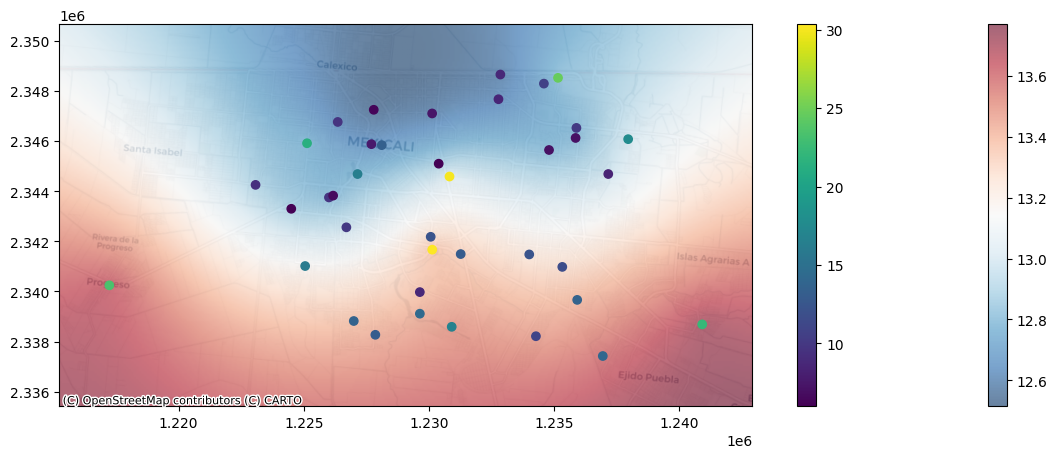

In [64]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.imshow(z, alpha=0.8, extent=(xmin, xmax, ymin, ymax))
cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)
g = ax.imshow(
    z,
    alpha=0.6,
    extent=(xmin, xmax, ymin, ymax),
    cmap="RdBu_r",
    origin="lower",
)
fig.colorbar(g)
temp.plot(ax=ax, column="mug/m3", legend=True)
fig.tight_layout()

# skgstat

In [309]:
crs = temp.to_crs("EPSG:4326").estimate_utm_crs()
coords = temp.to_crs(crs).get_coordinates().to_numpy()

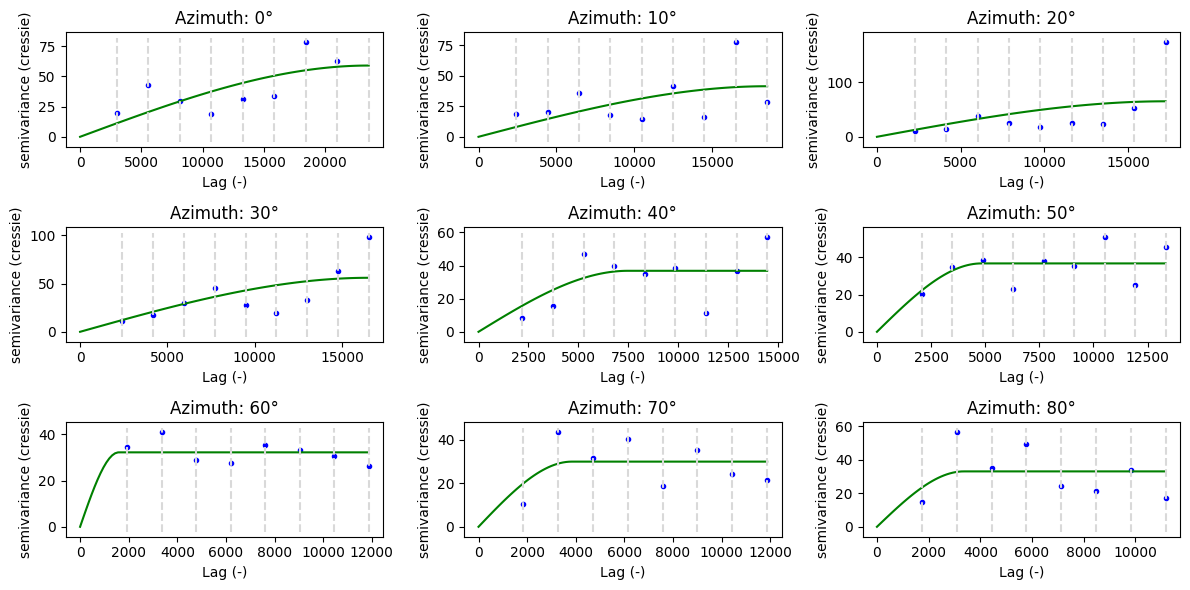

In [350]:
fig, axes = plt.subplots(3, 3, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    v = DirectionalVariogram(
        coords,
        temp["mug/m3"].to_numpy(),
        n_lags=25,
        azimuth=i * 10,
        tolerance=45,
        bin_func="sturges",
        model="spherical",
        estimator="cressie",
    )
    v.plot(show=False, axes=ax)
    ax.set_title(f"Azimuth: {i * 10}°")
fig.tight_layout()

In [359]:
final_v = DirectionalVariogram(
    coords,
    temp["mug/m3"].to_numpy(),
    azimuth=45,
    n_lags=10,
    bin_func="sturges",
    model="matern",
    estimator="cressie",
)

ok = OrdinaryKriging(final_v, min_points=5, max_points=20, n_jobs=1)

In [360]:
xmin, ymin, xmax, ymax = temp.to_crs(crs).total_bounds

offset = 1000
xmin -= offset
xmax += offset
ymin -= offset
ymax += offset

xrange = np.linspace(xmin, xmax, 200)
yrange = np.linspace(ymin, ymax, 200)

xx, yy = np.meshgrid(xrange, yrange)
field = ok.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)

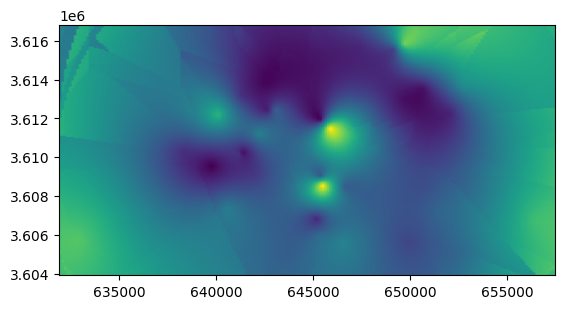

In [ ]:
plt.imshow(field, extent=(xmin, xmax, ymin, ymax), origin="lower", cmap="viridis")